# Predicting Saudi real-estate prices on the GPU

**What this is.** 529,431 sale listings, three models fitted on one NVIDIA RTX 3090. Everything
below — the frames, the splits, the training and the scoring — runs on the GPU.

- **two markets, not one.** A villa is priced as a whole; a plot of bare land is priced by its
  area. They are modelled separately, and a single pooled model is included to show what that
  separation is worth
- **the land model predicts price per square metre (SAR/m²), not total price.** Multiply by the
  plot area to get a price. Every land number in this notebook is in SAR/m²
- **models compared** — XGBoost against three linear baselines (plain, ridge, lasso), all on the
  same 70/30 split with `random_state=42` and the same hyper-parameter search
- **prices are fitted as `log1p`** — listings span four orders of magnitude, so on the raw scale
  a handful of them would own the loss. Every reported error undoes the transform

In [1]:
import random
import threading
import time
from collections.abc import Callable, Iterator
from contextlib import contextmanager

import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynvml
import xgboost as xgb
from cuml.linear_model import Lasso, LinearRegression, Ridge
from cuml.model_selection import train_test_split
from cuml.preprocessing import StandardScaler

In [2]:
pynvml.nvmlInit()
GPU = pynvml.nvmlDeviceGetHandleByIndex(0)
POLL_S = 0.05
PREDICT_REPEATS = 20
SAMPLED_MIN = 20      # below this, utilisation is one stale counter, not an average


def gpu_stats() -> tuple[float, float]:
    """Instantaneous GPU utilisation (%) and memory in use (GB)."""
    return (float(pynvml.nvmlDeviceGetUtilizationRates(GPU).gpu),
            pynvml.nvmlDeviceGetMemoryInfo(GPU).used / 1024**3)


@contextmanager
def timed(store: list[dict[str, float]]) -> Iterator[None]:
    """Time a block while polling the GPU on a worker thread.

    Two things this has to get right. The device is synchronised before the clock
    stops, because cuDF, cuPy and cuML queue their work asynchronously and an
    unsynchronised timer measures how fast Python launched the kernels rather than
    how long the GPU ran them. And utilisation is sampled during the block, not read
    after it, when the card has already gone idle.
    """
    samples: list[tuple[float, float]] = []
    stop = threading.Event()

    def poll() -> None:
        while not stop.is_set():
            samples.append(gpu_stats())
            stop.wait(POLL_S)

    worker = threading.Thread(target=poll, daemon=True)
    worker.start()
    t0 = time.perf_counter()
    try:
        yield
    finally:
        cp.cuda.runtime.deviceSynchronize()
        elapsed = time.perf_counter() - t0
        stop.set()
        worker.join()
        store.append({"seconds": elapsed,
                      "util": float(np.mean([s[0] for s in samples])) if samples else 0.0,
                      "mem": max((s[1] for s in samples), default=0.0),
                      "n": float(len(samples))})


def cost(blocks: list[dict[str, float]]) -> dict[str, float]:
    """Fold the timed blocks of one model into total seconds and mean utilisation.

    Utilisation is weighted by duration so a millisecond of tuning cannot outweigh a
    minute of search, and is reported as NaN when the model trained too fast to poll.
    """
    seconds = sum(b["seconds"] for b in blocks)
    sampled = sum(b["n"] for b in blocks) >= SAMPLED_MIN
    return {"train_s": seconds,
            "gpu_util_%": (sum(b["util"] * b["seconds"] for b in blocks) / seconds
                           if sampled else float("nan")),
            "mem_peak_GB": max(b["mem"] for b in blocks)}


def predict_speed(predict_fn: Callable[[object], object], X: object, repeats: int) -> float:
    """Rows scored per second, averaged over repeated passes after a warm-up call."""
    predict_fn(X[:1000])
    cp.cuda.runtime.deviceSynchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        predict_fn(X)
    cp.cuda.runtime.deviceSynchronize()
    return len(X) * repeats / (time.perf_counter() - t0)


print(pynvml.nvmlDeviceGetName(GPU), "| util %, mem GB:", gpu_stats())

NVIDIA GeForce RTX 3090 | util %, mem GB: (23.0, 2.12591552734375)


In [3]:
df = cudf.read_parquet("../data/SELL_REAL_ESTATE_FOR_MODELING.parquet")

# Bounds drop listings that are not real prices: a 1 SAR villa, a 10 billion SAR plot.
# Land is bounded on price per m2 rather than on price, since a large cheap plot and a
# small expensive one are both ordinary.
is_land = df["type_land"] == 1

d_built = df[~is_land]
d_built = d_built[(d_built.price >= 50_000) & (d_built.price <= 50_000_000)]

d_land_full = df[is_land]
d_land_full = d_land_full[(d_land_full.price >= 1_000) & (d_land_full.area_m2 > 0)]
ppm = d_land_full.price / d_land_full.area_m2
d_land_full = d_land_full[(ppm >= 10) & (ppm <= 20_000)]

# A plot has no bedrooms, no kitchen and no furnishing. Those columns are constant or
# noise on bare ground, so the land model gets the eight that carry signal.
KEEP_LAND = ["city", "district", "area_m2", "street_width_m",
             "is_corner", "is_investment", "near_masjid", "is_negotiable"]
d_land = d_land_full[KEEP_LAND + ["price"]]

# The pooled model sees exactly the same rows, just not split by market -- so the
# comparison isolates the split itself rather than the filtering.
d_all = cudf.concat([d_built, d_land_full])

DROP_BUILT = ["living_rooms_missing"]   # constant once land is removed

print(f"pooled {len(d_all):,}    built {len(d_built):,}    land {len(d_land):,}")

pooled 529,431    built 319,282    land 210,149


### The three targets

Bare land is **40% of the market** and behaves differently from everything else: two plots in
the same district differ mostly by size, so the price that matters is the price per square metre.
Built property is priced as a whole. Fitting both with one model forces a single set of splits to
serve two different questions, and the pooled row in the table below is what that costs.

Land is therefore fitted on `price / area_m2` and **scored in SAR/m²**. That is not a technicality:
scored in total riyals, the land models look far closer together than they are, because
multiplying a prediction back by an unbounded plot area lets a handful of enormous plots decide
the score.

In [4]:
def prep(data: cudf.DataFrame, drop: tuple[str, ...], divisor: str | None) -> tuple:
    """Encode and split 70/30. `divisor` makes the target price per unit of that column.

    Text columns become integer codes kept as categories, so XGBoost splits on the
    category natively instead of reading the code as a magnitude.
    """
    target = data["price"] / data[divisor] if divisor else data["price"]
    y = cudf.Series(cp.log1p(target.to_cupy()), index=data.index)
    X = data.drop(columns=["price", *drop])
    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category").cat.codes.astype("int32").astype("category")
    return train_test_split(X, y, test_size=0.3, random_state=42)


def prep_linear(data: cudf.DataFrame, drop: tuple[str, ...], divisor: str | None) -> tuple:
    """The same split, prepared for a linear model.

    Three differences from `prep`, all forced: no native categoricals, so `city` and
    `district` become plain integers; constant columns are dropped, because a zero
    standard deviation makes `StandardScaler` divide by zero and hand cuML a NaN it
    refuses to fit; and the scaler is fitted on the training rows only, so the test
    split's mean and variance never leak into training.
    """
    target = data["price"] / data[divisor] if divisor else data["price"]
    y = cudf.Series(cp.log1p(target.to_cupy()), index=data.index)
    X = data.drop(columns=["price", *drop])
    for c in X.columns:
        if not cudf.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype("category").cat.codes.astype("int32")
    X_tr, X_te, y_tr, y_te = train_test_split(X.astype("float32"), y,
                                              test_size=0.3, random_state=42)
    keep = [c for c in X_tr.columns if float(X_tr[c].std()) > 0]
    scaler = StandardScaler().fit(X_tr[keep])
    X_tr_s, X_te_s = scaler.transform(X_tr[keep]), scaler.transform(X_te[keep])
    # transform resets the column names and the index; put both back, or every later
    # lookup lands on rows y has never heard of
    X_tr_s.columns, X_te_s.columns = keep, keep
    X_tr_s.index, X_te_s.index = X_tr.index, X_te.index
    return X_tr_s, X_te_s, y_tr.astype("float32"), y_te.astype("float32")


def metrics(y_log, p_log, n_features: int) -> dict[str, float]:
    """Accuracy in the unit the model predicts -- SAR/m2 for land, SAR elsewhere.

    Three R2 on purpose. `R2_log` scores `log1p(target)`, the quantity actually
    optimised, and is the honest measure of the fit. `R2` scores the un-logged price,
    which is what a reader means by the word. `Adj_R2` discounts `R2` by the number of
    features, so an 8-column model and a 37-column one can be set side by side.

    All three compare models fitted on the SAME target. None of them compares across
    targets: R2 is the share of a target's variance explained, and the pooled target
    mixes two markets, so its variance -- and therefore its R2 -- is larger for reasons
    that have nothing to do with the model being better. Use MedAPE for that.
    """
    y_log = cp.asarray(y_log).astype(cp.float64)
    p_log = cp.asarray(p_log).ravel().astype(cp.float64)
    true, pred = cp.expm1(y_log), cp.expm1(p_log)
    err = pred - true
    ape = cp.abs(err) / true
    n = len(true)
    r2 = float(1 - cp.sum(err ** 2) / cp.sum((true - true.mean()) ** 2))
    return {"R2_log": float(1 - cp.sum((y_log - p_log) ** 2)
                            / cp.sum((y_log - y_log.mean()) ** 2)),
            "R2": r2,
            "Adj_R2": 1 - (1 - r2) * (n - 1) / (n - n_features - 1),
            "RMSE": float(cp.sqrt(cp.mean(err ** 2))),
            "MAE": float(cp.mean(cp.abs(err))),
            "MedAPE%": float(cp.median(ape) * 100),
            "within_10%": float((ape <= 0.10).mean() * 100)}

In [5]:
# Regularised on purpose. A wider grid -- depth 12, one row per leaf, no penalty -- scores
# marginally better on test and triples the train/test gap, which is capacity spent on
# memorising the training rows.
PARAMS = {"n_estimators":     [300, 500, 800, 1200],
          "learning_rate":    [0.02, 0.03, 0.05],
          "max_depth":        [4, 5, 6, 8],
          "min_child_weight": [10, 20, 50],
          "subsample":        [0.7, 0.8],
          "colsample_bytree": [0.6, 0.8],
          "reg_lambda":       [5, 20, 50]}
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0]


def booster_params(p: dict, seed: int) -> dict:
    """Translate a sampled parameter set into native booster parameters."""
    return {"device": "cuda", "tree_method": "hist", "max_cat_to_onehot": 1,
            "objective": "reg:squarederror", "eval_metric": "rmse",
            "eta": p["learning_rate"], "max_depth": p["max_depth"],
            "min_child_weight": p["min_child_weight"], "subsample": p["subsample"],
            "colsample_bytree": p["colsample_bytree"], "lambda": p["reg_lambda"],
            "seed": seed}


def search(X, y, n_iter: int, folds: int, seed: int) -> dict:
    """Random search with a fixed round budget per candidate.

    No early stopping: the number of rounds is sampled like every other parameter, and
    each fold is scored once after training ends. Stopping on a fold and then scoring
    that same fold reports the best point of a curve the fold chose itself.
    """
    rng = random.Random(seed)
    fold_id = cp.random.RandomState(seed).randint(0, folds, size=len(X))
    best = (np.inf, None)
    for i in range(n_iter):
        p = {k: rng.choice(v) for k, v in PARAMS.items()}
        errs = []
        for f in range(folds):
            tr, va = fold_id != f, fold_id == f
            tr = cudf.Series(tr, index=X.index)
            va = cudf.Series(va, index=X.index)
            dtr = xgb.QuantileDMatrix(X[tr], y[tr], enable_categorical=True)
            dva = xgb.QuantileDMatrix(X[va], y[va], enable_categorical=True, ref=dtr)
            bst = xgb.train(booster_params(p, seed), dtr,
                            num_boost_round=p["n_estimators"], verbose_eval=False)
            pred = cp.asarray(bst.predict(dva)).ravel()
            errs.append(float(cp.sqrt(cp.mean((cp.asarray(y[va].to_cupy()) - pred) ** 2))))
        rmse = float(np.mean(errs))
        best = min(best, (rmse, p), key=lambda b: b[0])
        print(f"    [{i+1}/{n_iter}] rmse={rmse:.4f}  best={best[0]:.4f}", flush=True)
    return best[1]


def refit(X, y, p: dict, seed: int) -> xgb.Booster:
    """Fit the winning candidate on the full training split."""
    dall = xgb.QuantileDMatrix(X, y, enable_categorical=True)
    return xgb.train(booster_params(p, seed), dall, num_boost_round=p["n_estimators"])


def build_linear(kind: str, alpha: float | None):
    """One cuML estimator. LinearRegression has no penalty, so it ignores alpha."""
    if kind == "linear":
        return LinearRegression()
    if kind == "ridge":
        return Ridge(alpha=alpha)
    if kind == "lasso":
        return Lasso(alpha=alpha)
    raise ValueError(f"unknown linear model: {kind}")


def pick_alpha(kind: str, X_tr, y_tr, folds: int, seed: int) -> float | None:
    """Choose the penalty by k-fold RMSE in log space, on the same folds as the search."""
    if kind == "linear":
        return None
    fold_id = cp.random.RandomState(seed).randint(0, folds, size=len(X_tr))
    scored = []
    for alpha in ALPHAS:
        errs = []
        for f in range(folds):
            tr = cudf.Series(fold_id != f, index=X_tr.index)
            va = cudf.Series(fold_id == f, index=X_tr.index)
            pred = cp.asarray(build_linear(kind, alpha).fit(X_tr[tr], y_tr[tr])
                              .predict(X_tr[va])).ravel()
            errs.append(float(cp.sqrt(cp.mean((cp.asarray(y_tr[va].to_cupy()) - pred) ** 2))))
        scored.append((float(np.mean(errs)), alpha))
    return min(scored)[1]

In [6]:
def train_xgb(data, target: str, drop: tuple[str, ...], divisor: str | None,
              unit: str, n_iter: int) -> tuple[dict[str, object], xgb.Booster, tuple]:
    """Search, refit and score one boosted model.

    Returns the table row, the booster, and its test split -- the last two so the
    pooled model can be re-scored on each market separately further down.
    """
    print(f"\n{target} / xgboost", flush=True)
    X_tr, X_te, y_tr, y_te = prep(data, drop, divisor)
    blocks: list[dict[str, float]] = []
    with timed(blocks):
        params = search(X_tr, y_tr, n_iter=n_iter, folds=3, seed=42)
    with timed(blocks):
        bst = refit(X_tr, y_tr, params, seed=42)

    test = metrics(y_te.to_cupy(), bst.inplace_predict(X_te), X_te.shape[1])
    train = metrics(y_tr.to_cupy(), bst.inplace_predict(X_tr), X_tr.shape[1])
    row = {"target": target, "model": "xgboost", "unit": unit,
           "features": X_tr.shape[1], **test,
           "gap": train["R2_log"] - test["R2_log"],
           "predict_rows_per_s": predict_speed(bst.inplace_predict, X_te, PREDICT_REPEATS),
           **cost(blocks)}
    return row, bst, (X_te, y_te)


def train_linear(data, target: str, drop: tuple[str, ...], divisor: str | None,
                 unit: str) -> list[dict[str, object]]:
    """Fit the three linear baselines on one target, measured the same way."""
    X_tr, X_te, y_tr, y_te = prep_linear(data, drop, divisor)
    rows = []
    for kind in ("linear", "ridge", "lasso"):
        print(f"\n{target} / {kind}", flush=True)
        blocks: list[dict[str, float]] = []
        with timed(blocks):
            alpha = pick_alpha(kind, X_tr, y_tr, folds=3, seed=42)
        model = build_linear(kind, alpha)
        with timed(blocks):
            model.fit(X_tr, y_tr)

        test = metrics(y_te.to_cupy(), model.predict(X_te), X_te.shape[1])
        train = metrics(y_tr.to_cupy(), model.predict(X_tr), X_tr.shape[1])
        rows.append({"target": target, "model": kind, "unit": unit,
                     "features": X_tr.shape[1], **test,
                     "gap": train["R2_log"] - test["R2_log"],
                     "predict_rows_per_s": predict_speed(model.predict, X_te,
                                                         PREDICT_REPEATS),
                     **cost(blocks)})
    return rows

In [7]:
pooled_row, pooled_bst, pooled_test = train_xgb(
    d_all, "all", drop=(), divisor=None, unit="SAR", n_iter=5)
built_row, _, _ = train_xgb(
    d_built, "built", drop=DROP_BUILT, divisor=None, unit="SAR", n_iter=5)
land_row, _, _ = train_xgb(
    d_land, "land", drop=(), divisor="area_m2", unit="SAR/m2", n_iter=5)

results = [pooled_row, built_row, land_row,
           *train_linear(d_built, "built", drop=DROP_BUILT, divisor=None, unit="SAR"),
           *train_linear(d_land, "land", drop=(), divisor="area_m2", unit="SAR/m2")]
print(f"\n{len(results)} models trained")


all / xgboost


    [1/5] rmse=0.3773  best=0.3773


    [2/5] rmse=0.3749  best=0.3749


    [3/5] rmse=0.3865  best=0.3749


    [4/5] rmse=0.3465  best=0.3465


...


built / lasso



land / linear



land / ridge



land / lasso



9 models trained


In [8]:
def segment_error(bst: xgb.Booster, X_te, y_te, mask) -> dict[str, float]:
    """Median error of one model on a subset of its own test rows.

    MedAPE and within-10% are ratios, so dividing both the prediction and the truth by
    the same plot area leaves them unchanged. That is what makes the pooled model --
    which predicts total price -- comparable to the land model, which predicts price
    per square metre. R2 is not comparable that way, and is deliberately absent here.
    """
    p = cp.asarray(bst.inplace_predict(X_te[mask])).ravel().astype(cp.float64)
    y = cp.asarray(y_te[mask].to_cupy()).astype(cp.float64)
    ape = cp.abs(cp.expm1(p) - cp.expm1(y)) / cp.expm1(y)
    return {"listings": int(mask.sum()),
            "MedAPE%": float(cp.median(ape) * 100),
            "within_10%": float((ape <= 0.10).mean() * 100)}


X_te_all, y_te_all = pooled_test
is_land_te = X_te_all["type_land"] == 1

split_vs_pooled = pd.DataFrame([
    {"market": "built", "model": "pooled (one model)",
     **segment_error(pooled_bst, X_te_all, y_te_all, ~is_land_te)},
    {"market": "built", "model": "split (built model)",
     "listings": None, "MedAPE%": built_row["MedAPE%"], "within_10%": built_row["within_10%"]},
    {"market": "land", "model": "pooled (one model)",
     **segment_error(pooled_bst, X_te_all, y_te_all, is_land_te)},
    {"market": "land", "model": "split (land model)",
     "listings": None, "MedAPE%": land_row["MedAPE%"], "within_10%": land_row["within_10%"]},
]).round({"MedAPE%": 1, "within_10%": 1})

print(split_vs_pooled.to_string(index=False, na_rep=""))

market               model  listings  MedAPE%  within_10%
 built  pooled (one model)   95697.0     10.1        49.4
 built split (built model)                9.9        50.4
  land  pooled (one model)   63133.0     13.7        39.3
  land  split (land model)               13.1        40.7


In [9]:
COLUMNS = ["target", "model", "unit", "features", "R2_log", "R2", "Adj_R2",
           "RMSE", "MAE", "MedAPE%", "within_10%", "gap",
           "train_s", "predict_Mrows_s", "gpu_util_%", "mem_peak_GB"]
ROUNDING = {"R2_log": 3, "R2": 3, "Adj_R2": 3, "RMSE": 1, "MAE": 1, "MedAPE%": 1,
            "within_10%": 1, "gap": 3, "train_s": 1, "predict_Mrows_s": 1,
            "gpu_util_%": 0, "mem_peak_GB": 2}

table = pd.DataFrame(results)
table["predict_Mrows_s"] = table["predict_rows_per_s"] / 1e6
table = table[COLUMNS].round(ROUNDING)

# na_rep marks the utilisation of models that finished too fast to be polled.
print(table.to_string(index=False, na_rep="--"))

target   model   unit  features  R2_log     R2  Adj_R2       RMSE       MAE  MedAPE%  within_10%    gap  train_s  predict_Mrows_s  gpu_util_%  mem_peak_GB
   all xgboost    SAR        37   0.904  0.269   0.269 40688923.9 1300371.8     11.3        45.4  0.013     45.5              2.9        85.0         2.93
 built xgboost    SAR        36   0.884  0.771   0.771  1422592.3  397582.1      9.9        50.4  0.023     40.6              3.1        80.0         3.19
  land xgboost SAR/m2         8   0.873  0.830   0.830     1049.8     509.6     13.1        40.7  0.021     36.6              4.1        82.0         2.99
 built  linear    SAR        35   0.543  0.233   0.233  2602934.0  954813.5     31.5        16.6 -0.003      0.1             79.7          --         2.99
 built   ridge    SAR        35   0.546  0.253   0.252  2569918.6  950997.5     31.1        16.9 -0.003      0.2             79.4          --         3.02
 built   lasso    SAR        35   0.546  0.252   0.251  2571465.4  950

## Results


**How to read the columns.** `R2_log` scores the model on what it optimises, `log1p(price)`, and
is the fairest measure of the fit. `R2` scores the actual price — it is what most people mean by
the word, and it punishes the few enormous listings hard. `Adj_R2` discounts `R2` by how many
features the model used. **Median error** is the middle listing's error, the number to quote to a
customer. **Within 10%** is the share of listings priced within a tenth of the truth.

### Accuracy — test split, in the unit each model predicts

| market | model | unit | R2_log | R2 | Adj R2 | avg error | median error | within 10% |
|---|---|---|---|---|---|---|---|---|
| all (pooled) | **xgboost** | SAR | 0.904 | 0.269 | 0.269 | 1,300,372 | 11.3% | 45.4% |
| built | **xgboost** | SAR | 0.884 | 0.771 | 0.771 | 397,582 | **9.9%** | 50.4% |
| built | linear | SAR | 0.543 | 0.233 | 0.233 | 954,814 | 31.5% | 16.6% |
| built | ridge | SAR | 0.546 | 0.253 | 0.252 | 950,998 | 31.1% | 16.9% |
| built | lasso | SAR | 0.546 | 0.252 | 0.251 | 950,977 | 31.1% | 16.8% |
| land | **xgboost** | SAR/m² | 0.873 | 0.830 | 0.830 | 510 | **13.1%** | 40.7% |
| land | linear | SAR/m² | 0.126 | −1.876 | −1.877 | 1,845 | 58.2% | 6.9% |
| land | ridge | SAR/m² | 0.126 | −1.875 | −1.875 | 1,845 | 58.2% | 6.9% |
| land | lasso | SAR/m² | 0.126 | −1.674 | −1.674 | 1,845 | 58.2% | 6.9% |

### Cost on the GPU

| model | training | scoring | GPU busy | GPU memory |
|---|---|---|---|---|
| xgboost · pooled | 46 s | 2.8M rows/s | 85% | 2.5 GB |
| xgboost · built | 41 s | 3.2M rows/s | 87% | 2.5 GB |
| xgboost · land | 35 s | 4.1M rows/s | 81% | 2.5 GB |
| the six linear models | under 1 s each | 54–81M rows/s | too fast to measure | 2.4–2.5 GB |


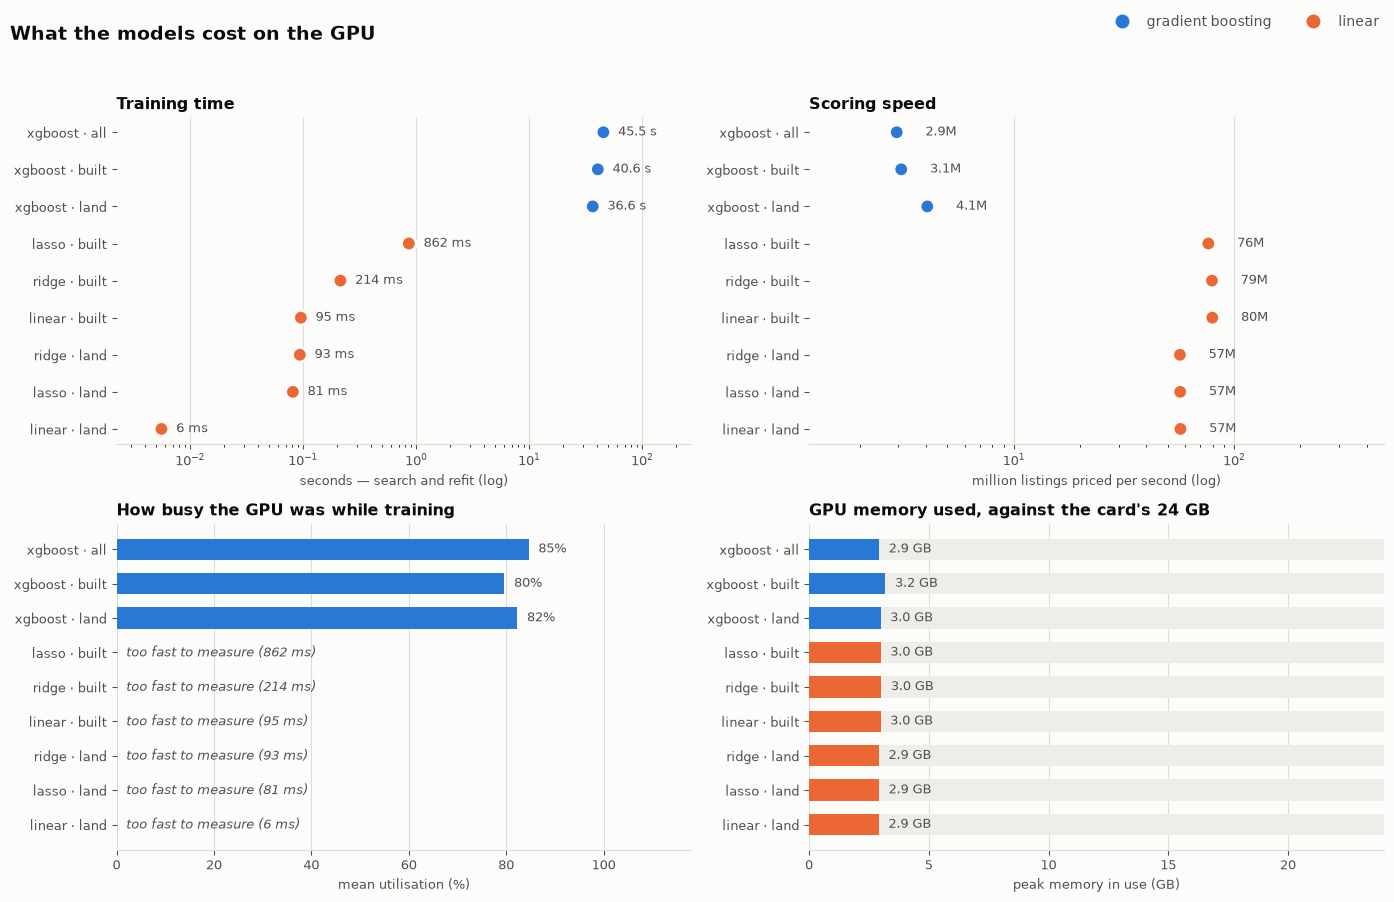

In [10]:
# Two families, two hues, assigned in fixed order and checked for colour-vision
# separation (worst adjacent pair dE 24.7 under protanopia). Text stays in ink
# colours -- a coloured mark beside a label carries the identity, the label itself
# never does, so the figure survives being printed in grey.
SURFACE, INK, INK_SOFT, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
FAMILY_COLOUR = {"gradient boosting": "#2a78d6", "linear": "#eb6834"}
TOTAL_GB = pynvml.nvmlDeviceGetMemoryInfo(GPU).total / 1024**3

perf = pd.DataFrame(results)
perf["label"] = perf["model"] + " · " + perf["target"]
perf["family"] = np.where(perf["model"] == "xgboost", "gradient boosting", "linear")
perf["predict_Mrows_s"] = perf["predict_rows_per_s"] / 1e6
# One ordering for all four panels, so a model can be tracked across them. Sorting
# each panel by its own value would repaint the ranking and break that.
perf = perf.sort_values("train_s", ascending=False).reset_index(drop=True)

colour = perf["family"].map(FAMILY_COLOUR).tolist()
y = np.arange(len(perf))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=SURFACE)


def dots(ax, values, fmt, title, xlabel):
    """A log axis reads as a ratio from an arbitrary origin if drawn as bars, so
    magnitude on a log scale gets dots plus a direct label instead."""
    ax.scatter(values, y, s=110, color=colour, zorder=3, edgecolor=SURFACE, linewidth=2)
    for yi, v in zip(y, values):
        ax.text(v * 1.35, yi, fmt(v), va="center", fontsize=9, color=INK_SOFT)
    ax.set_xscale("log")
    ax.set_xlim(min(values) / 2.5, max(values) * 6)
    ax.set_title(title, loc="left", fontweight="bold", color=INK, fontsize=11.5)
    ax.set_xlabel(xlabel, color=INK_SOFT, fontsize=9.5)


def seconds_label(v: float) -> str:
    """Sub-second fits read as "0.0 s"; milliseconds are the honest unit there."""
    return f"{v*1000:.0f} ms" if v < 1 else f"{v:,.1f} s"


dots(axes[0, 0], perf["train_s"], seconds_label,
     "Training time", "seconds — search and refit (log)")
dots(axes[0, 1], perf["predict_Mrows_s"], lambda v: f"{v:,.0f}M" if v >= 10 else f"{v:.1f}M",
     "Scoring speed", "million listings priced per second (log)")

# Utilisation of a model that trained in milliseconds is one stale driver counter.
# Those rows get no bar and say so, rather than a number that looks measured.
ax = axes[1, 0]
util = perf["gpu_util_%"].to_numpy(dtype=float)
ax.barh(y, np.nan_to_num(util), height=0.62, color=colour, zorder=3)
for yi, (v, secs) in enumerate(zip(util, perf["train_s"])):
    if np.isnan(v):
        ax.text(2, yi, f"too fast to measure ({secs*1000:.0f} ms)", va="center",
                fontsize=9, color=INK_SOFT, style="italic")
    else:
        ax.text(v + 2, yi, f"{v:.0f}%", va="center", fontsize=9, color=INK_SOFT)
ax.set_xlim(0, 118)
ax.set_title("How busy the GPU was while training", loc="left", fontweight="bold",
             color=INK, fontsize=11.5)
ax.set_xlabel("mean utilisation (%)", color=INK_SOFT, fontsize=9.5)

# Drawn against the whole card rather than against each other: the story is the
# headroom, and a zoomed axis would turn a 0.3 GB spread into a dramatic one.
ax = axes[1, 1]
ax.barh(y, TOTAL_GB, height=0.62, color="#eeedea", zorder=2)
ax.barh(y, perf["mem_peak_GB"], height=0.62, color=colour, zorder=3)
for yi, v in zip(y, perf["mem_peak_GB"]):
    ax.text(v + 0.4, yi, f"{v:.1f} GB", va="center", fontsize=9, color=INK_SOFT)
ax.set_xlim(0, TOTAL_GB)
ax.set_title(f"GPU memory used, against the card's {TOTAL_GB:.0f} GB", loc="left",
             fontweight="bold", color=INK, fontsize=11.5)
ax.set_xlabel("peak memory in use (GB)", color=INK_SOFT, fontsize=9.5)

for ax in axes.flat:
    ax.set_facecolor(SURFACE)
    ax.set_yticks(y, perf["label"], fontsize=9.5, color=INK)
    ax.invert_yaxis()
    ax.grid(True, axis="x", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=9, color=c, label=f)
           for f, c in FAMILY_COLOUR.items()]
fig.legend(handles=handles, loc="upper right", frameon=False, ncols=2,
           bbox_to_anchor=(0.995, 1.005), fontsize=10, labelcolor=INK_SOFT)
fig.suptitle("What the models cost on the GPU", x=0.008, ha="left", fontsize=14,
             fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()